# Automated Mortgage Underwriting & Compliance Swarm (Agent Handoffs)

This notebook demonstrates a **Multi-Agent Swarm with Dynamic Handoffs** implemented in pure LangChain (`create_agent`) and LangGraph.

### System Concept:
In mortgage loan processing, applications pass through multiple specialized stages. Instead of having a single monolithic agent attempt to do everything, we define four specialized agent subgraphs and route between them using the **Handoffs Pattern** via the `Command(goto=..., graph=Command.PARENT)` API.

### Swarm Architecture:
```
                       ┌────────────────────────┐
                       │      START Node        │
                       └───────────┬────────────┘
                                   │
                                   ▼
                       ┌────────────────────────┐
                       │ Router (Active Agent)  │◄─────────────────┐
                       └───────────┬────────────┘                  │
                                   │ (Routes new turn)             │
    ┌───────────────────────┬──────┴────────────────┬──────────────┐       │ (Handoffs via
    ▼                       ▼                       ▼              ▼       │  Command.PARENT)
┌───────────────┐       ┌───────────────┐       ┌───────────────┐┌───────────────┐ │
│Loan Intake    │       │ Underwriter   │       │ Loan Structur-││ Compliance    │─┘
│Agent (Front)  │       │ Agent (Rules) │       │ er Agent      ││ Agent (Audit) │
└───────────────┘       └───────────────┘       └───────────────┘└───────────────┘
    │                       │                       │              │
    └───────────────────────┼───────────────────────┴──────────────┘
                            ▼
                       ┌────────────────────────┐
                       │        END Node        │
                       └────────────────────────┘
```

1. **`LoanIntakeAgent`**: Front-facing agent that welcomes the customer and collects financial metrics (income, debt, loan amount, downpayment).
2. **`UnderwriterAgent`**: Queries the Credit Bureau, checks the credit score and calculates the **Debt-to-Income (DTI)** ratio. Approves or escalates to restructuring.
3. **`LoanStructurerAgent`**: Optimizes terms (calculating required additional downpayment) to lower DTI to the $43\%$ limit, and negotiates with the customer.
4. **`ComplianceAgent`**: Runs AML/KYC checks. If flagged, loops back to the intake agent to request documentation.

## 1. Setup & Environment Variables
Set up the API keys and initialize the chat model.

In [1]:
import os
from getpass import getpass
from dotenv import load_dotenv

# Load keys from root directory .env if present
load_dotenv(dotenv_path="../.env")

if "GEMINI_API_KEY" not in os.environ:
    if "GOOGLE_API_KEY" in os.environ:
        os.environ["GEMINI_API_KEY"] = os.environ["GOOGLE_API_KEY"]
    else:
        os.environ["GEMINI_API_KEY"] = getpass("Enter your GEMINI API Key: ")

## 2. Define Shared State Schema & Mock Databases
We'll define the databases for credit ratings and compliance blacklists, and setup the shared `MortgageState` TypedDict.

In [2]:
from typing import TypedDict, Annotated, Any
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

# Mock Credit Bureau Database
CREDIT_BUREAU_DB = {
    "Alice Smith": {"credit_score": 750, "monthly_debt": 200.0},
    "Bob Jones": {"credit_score": 640, "monthly_debt": 500.0},
    "Charlie Brown": {"credit_score": 680, "monthly_debt": 2000.0}
}

# Mock AML Anti-Money Laundering Watchlist
AML_WATCHLIST = [
    "Bob Jones",
    "Evil Villain"
]

# Parent and Sub-graph State Schema
class MortgageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    active_agent: str
    loan_application: dict      # name, gross_income, loan_amount, downpayment, employment
    credit_report: dict         # credit_score, monthly_debt
    underwriting_decision: dict    # status (Approved/Escalated), dti, ltv, reason
    compliance_audit: dict      # status (Clear/Flagged), reason

## 3. Implement Swarm Handoff Tools
Each tool will update the state keys and use `Command(goto=..., graph=Command.PARENT)` to route execution to the sibling node in the parent orchestrator.

In [ ]:
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from langchain_core.messages import AIMessage, ToolMessage

# 1. Intake Agent Handoff Tool
@tool("submit_loan_application")
def submit_loan_application(
    name: str,
    gross_income: float,
    loan_amount: float,
    downpayment: float,
    employment_status: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Submit the gathered loan application details to initiate underwriting."""
    loan_app = {
        "name": name,
        "gross_income": gross_income,
        "loan_amount": loan_amount,
        "downpayment": downpayment,
        "employment_status": employment_status
    }
    return Command(
        goto="underwriter",
        graph=Command.PARENT,
        update={
            "loan_application": loan_app,
            "active_agent": "underwriter",
            "messages": [
                ToolMessage(content=f"Submitted loan application for {name}", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Application submitted for {name}. Routing to Underwriting...")
            ]
        }
    )

# 2. Underwriter Agent Tools
@tool("fetch_credit_report")
def fetch_credit_report(
    name: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Query the Credit Bureau database for credit score and monthly debts of the applicant."""
    report = CREDIT_BUREAU_DB.get(name, {"credit_score": 580, "monthly_debt": 0.0})
    return Command(
        update={
            "credit_report": report,
            "messages": [
                ToolMessage(content=f"Credit report retrieved for {name}", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Tools]: Retrieved Credit Bureau report for {name}: Credit Score = {report['credit_score']}, Existing Monthly Debt = ${report['monthly_debt']:.2f}.")
            ]
        }
    )

@tool("approve_underwriting")
def approve_underwriting(
    state: Annotated[dict, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Approve the underwriting check and transfer control to Compliance."""
    loan = state.get("loan_application", {})
    credit = state.get("credit_report", {})
    
    gross_income = loan.get("gross_income", 1.0)
    loan_amount = loan.get("loan_amount", 0.0)
    monthly_debt = credit.get("monthly_debt", 0.0)
    credit_score = credit.get("credit_score", 0.0)
    
    # Estimate mortgage payment: 0.56% of loan amount monthly
    mortgage_payment = loan_amount * 0.0056  # 2240
    dti = ((monthly_debt + mortgage_payment) / gross_income) * 100 #20.33
    
    decision = {"status": "Approved", "dti": f"{dti:.2f}%", "credit_score": credit_score}
    return Command(
        goto="compliance",
        graph=Command.PARENT,
        update={
            "underwriting_decision": decision,
            "active_agent": "compliance",
            "messages": [
                ToolMessage(content="Underwriting approved", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Underwriting approved (DTI: {dti:.1f}%, Score: {credit_score}). Routing to Compliance...")
            ]
        }
    )

@tool("escalate_to_restructuring")
def escalate_to_restructuring(
    reason: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Escalate the underwriting check to the Loan Structurer."""
    decision = {"status": "Escalated", "reason": reason}
    return Command(
        goto="loan_structurer",
        graph=Command.PARENT,
        update={
            "underwriting_decision": decision,
            "active_agent": "loan_structurer",
            "messages": [
                ToolMessage(content=f"Underwriting escalated: {reason}", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Escalating application to Loan Structurer due to: {reason}.")
            ]
        }
    )

# 3. Loan Structurer Tools
@tool("propose_restructuring_options")
def propose_restructuring_options(
    state: Annotated[dict, InjectedState]
) -> str:
    """Calculate and return the options to lower DTI down to the conforming limit of 43%."""
    loan = state.get("loan_application", {})
    credit = state.get("credit_report", {})
    
    gross_income = loan.get("gross_income", 1.0)
    loan_amount = loan.get("loan_amount", 0.0)
    existing_downpayment = loan.get("downpayment", 0.0)
    existing_debt = credit.get("monthly_debt", 0.0)
    
    # Target mortgage payment allowed for 43% DTI
    max_allowed_debt = 0.43 * gross_income
    max_mortgage_payment = max_allowed_debt - existing_debt
    
    if max_mortgage_payment <= 0:
        return "Error: Applicant existing debt already exceeds 43% DTI limit. Restructuring cannot approve."
        
    # Calculate conforming loan amount: mortgage_payment = loan * 0.0056
    conforming_loan = max_mortgage_payment / 0.0056 
    required_reduction = loan_amount - conforming_loan
    
    new_downpayment = existing_downpayment + required_reduction
    # Round downpayment to nearest thousand
    new_downpayment_rounded = int(round(new_downpayment / 1000.0) * 1000.0)
    new_loan_amount_rounded = int(loan_amount + existing_downpayment - new_downpayment_rounded)
    
    return (
        f"Calculated conforming terms:\n"
        f"- Required Downpayment: ${new_downpayment_rounded:,} (Increased from ${existing_downpayment:,})\n"
        f"- New Loan Amount: ${new_loan_amount_rounded:,} (Reduced from ${loan_amount:,})\n"
        f"- Estimated New DTI: 43.0%"
    )

@tool("accept_restructured_terms")
def accept_restructured_terms(
    new_downpayment: float,
    new_loan_amount: float,
    state: Annotated[dict, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Accept the new restructured terms agreed upon by the applicant."""
    loan = state.get("loan_application", {}).copy()
    loan["downpayment"] = new_downpayment
    loan["loan_amount"] = new_loan_amount
    
    return Command(
        goto="underwriter",
        graph=Command.PARENT,
        update={
            "loan_application": loan,
            "active_agent": "underwriter",
            "messages": [
                ToolMessage(content=f"Accepted restructured terms (Downpayment=${new_downpayment}, Loan=${new_loan_amount})", tool_call_id=tool_call_id),
                AIMessage(content=f"[System Handoff]: Applicant accepted restructured terms (Downpayment: ${new_downpayment:,}, Loan: ${new_loan_amount:,}). Returning to Underwriter...")
            ]
        }
    )

# 4. Compliance Agent Tools
@tool("verify_compliance")
def verify_compliance(
    name: str,
    tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Run KYC verification and AML watchlist checks against the database."""
    is_flagged = name in AML_WATCHLIST
    if is_flagged:
        audit = {"status": "Flagged", "reason": "Name matches compliance watchlist database record"}
        return Command(
            goto="loan_intake",
            graph=Command.PARENT,
            update={
                "compliance_audit": audit,
                "active_agent": "loan_intake",
                "messages": [
                    ToolMessage(content="Compliance verification failed: Flagged on watchlist", tool_call_id=tool_call_id),
                    AIMessage(content=f"[System Handoff]: Compliance check FAILED (Flagged). Routing back to Loan Intake to gather identity verification...")
                ]
            }
        )
    else:
        audit = {"status": "Clear", "reason": "All KYC/AML verification checks passed successfully"}
        return Command(
            update={
                "compliance_audit": audit,
                "messages": [
                    ToolMessage(content="Compliance verification passed", tool_call_id=tool_call_id),
                    AIMessage(content="[System Tools]: Compliance audit cleared successfully.")
                ]
            }
        )


## 4. Instantiate Sub-Agents using `create_agent`
Pass the shared state schema to each agent definition so they share access to variables like `loan_application` and `credit_report`.

In [4]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

# Chat model
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

# 1. Loan Intake Agent
loan_intake_agent = create_agent(
    model=llm,
    tools=[submit_loan_application],
    system_prompt=(
        "You are a friendly Front-end Loan Intake Agent. Your job is to gather applicant details: "
        "applicant name, gross monthly income, requested mortgage loan amount, downpayment, and employment status. "
        "When you have all details, execute submit_loan_application. "
        "If a customer has been flagged by compliance, politely ask them to upload validation documents or verify their legal spelling."
    ),
    state_schema=MortgageState,
    name="loan_intake"
)

# 2. Underwriter Agent
underwriter_agent = create_agent(
    model=llm,
    tools=[fetch_credit_report, approve_underwriting, escalate_to_restructuring],
    system_prompt=(
        "You are a Mortgage Underwriting Agent. Your goal is to evaluate creditworthiness. "
        "First, pull the credit report using fetch_credit_report tool. "
        "Compute the DTI (Monthly Debt + Mortgage Payment) / Gross Monthly income. (Estimate Mortgage Payment as 0.0056 * loan_amount). "
        "- If Credit Score is >= 620 and DTI is <= 43%, call approve_underwriting. "
        "- If DTI is > 43% or Credit Score is marginal, call escalate_to_restructuring with the reason."
    ),
    state_schema=MortgageState,
    name="underwriter"
)

# 3. Loan Structurer Agent
loan_structurer_agent = create_agent(
    model=llm,
    tools=[propose_restructuring_options, accept_restructured_terms],
    system_prompt=(
        "You are a Loan Structurer. Your job is to restructure loans to meet conforming guidelines. "
        "First, call propose_restructuring_options to calculate required downpayments. "
        "Propose this new option to the customer. If they accept, execute accept_restructured_terms with the new terms."
    ),
    state_schema=MortgageState,
    name="loan_structurer"
)

# 4. Compliance Agent
compliance_agent = create_agent(
    model=llm,
    tools=[verify_compliance],
    system_prompt=(
        "You are a Compliance Agent. Your job is to run KYC and AML watchdog security audits. "
        "Execute the verify_compliance tool. "
        "If the audit fails, explain why and the system will automatically route back to Intake. "
        "If clear, congratulate the user on final pre-approval."
    ),
    state_schema=MortgageState,
    name="compliance"
)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


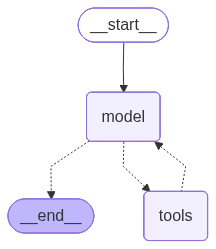

In [5]:
loan_intake_agent

## 5. Construct Parent Graph Orchestrator
We'll assemble the parent StateGraph and configure dynamic start routing based on the state variable `active_agent`. A checkpointer is attached to persist states between turns.

In [6]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

builder = StateGraph(MortgageState)

# Add agent subgraph nodes
builder.add_node("loan_intake", loan_intake_agent)
builder.add_node("underwriter", underwriter_agent)
builder.add_node("loan_structurer", loan_structurer_agent)
builder.add_node("compliance", compliance_agent)

# Conditional routing from START node based on active_agent
def route_active_agent(state: MortgageState):
    return state.get("active_agent", "loan_intake")

builder.add_conditional_edges(
    START,
    route_active_agent,
    ["loan_intake", "underwriter", "loan_structurer", "compliance"]
)

# Node exits default to END if no explicit Command is returned
builder.add_edge("loan_intake", END)
builder.add_edge("underwriter", END)
builder.add_edge("loan_structurer", END)
builder.add_edge("compliance", END)



In [7]:
builder

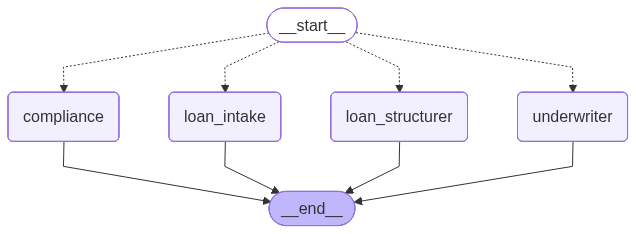

In [8]:
# Database and compilation
import os
if os.path.exists("mortgage_checkpoints.db"):
    try:
        os.remove("mortgage_checkpoints.db")
    except Exception:
        pass
conn = sqlite3.connect("mortgage_checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)
mortgage_swarm = builder.compile(checkpointer=memory)

mortgage_swarm
#print("Mortgage Swarm Graph successfully compiled!")

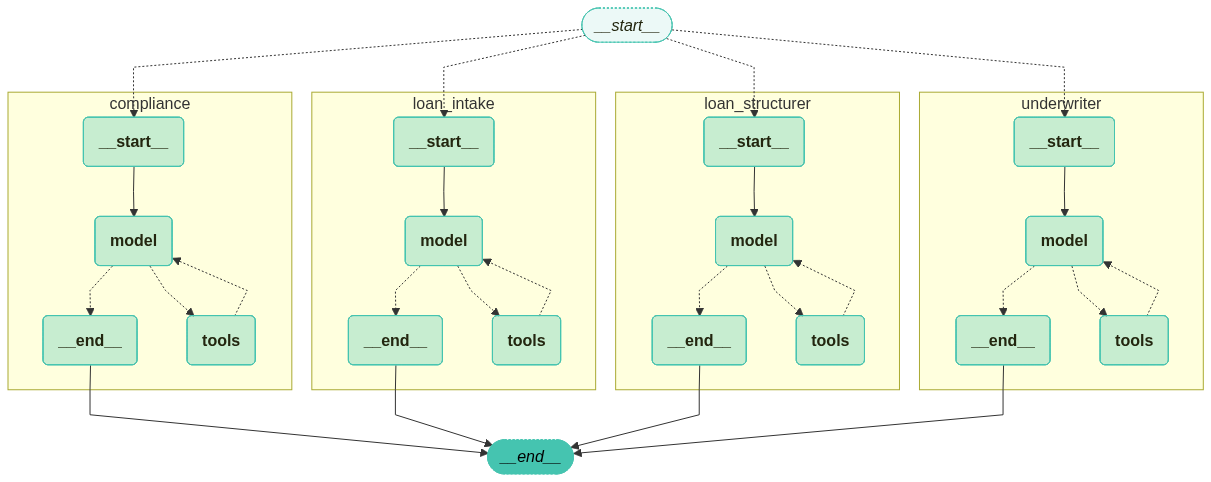

In [9]:
from langchain_opentutorial.graphs import visualize_graph
visualize_graph(mortgage_swarm, xray=True)

## 6. Demonstration Scenarios
We'll simulate three mortgage application scenarios in a multi-turn fashion.

### Scenario 1: Standard Conforming Application (Approved Directly)
Applicant: **Alice Smith** (Income: $12,000, Debt: $200, Credit: 750, Requested: $400,000, Downpayment: $100,000).

In [10]:
config_1 = {"configurable": {"thread_id": "thread_scenario_1"}}

# Turn 1: Customer submits figures
msg1 = "Hello, I am Alice Smith. I want to apply for a mortgage. Gross income: $12,000, requested loan: $400,000, downpayment: $100,000, employed status."
print(f"User Message: {msg1}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg1)], "active_agent": "loan_intake"}, config=config_1)

print("\n--- Turn 1 Final Agent Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: Hello, I am Alice Smith. I want to apply for a mortgage. Gross income: $12,000, requested loan: $400,000, downpayment: $100,000, employed status.


--- Turn 1 Final Agent Output ---
[{'type': 'text', 'text': '\n\nCongratulations, Alice Smith! Your compliance audit has been cleared successfully. You have received final pre-approval for your mortgage application.'}]
Active Agent: compliance


### Scenario 2: High Debt Application (Restructuring Loop)
Applicant: **Charlie Brown** (Income: $10,000, Debt: $2,000, Credit: 680, Requested: $500,000, Downpayment: $100,000).

In [11]:
config_2 = {"configurable": {"thread_id": "thread_scenario_2"}}

# Turn 1: Initial submission
msg_charlie_1 = "Hello, I am Charlie Brown. Applying for mortgage. gross income is $10,000, requested loan: $500,000, downpayment: $100,000, employed."
print(f"User Message: {msg_charlie_1}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg_charlie_1)], "active_agent": "loan_intake"}, config=config_2)

print("\n--- Charlie Turn 1 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}\n")



User Message: Hello, I am Charlie Brown. Applying for mortgage. gross income is $10,000, requested loan: $500,000, downpayment: $100,000, employed.


--- Charlie Turn 1 Output ---
[{'type': 'text', 'text': 'Hello Charlie, thank you for your patience while we reviewed your application.\n\nBased on your current financial profile, your Debt-to-Income (DTI) ratio is at 48%, which exceeds the conforming limit of 43%. To bring your application into compliance, we have calculated a restructuring option for you:\n\n*   **New Downpayment:** $168,000 (an increase of $68,000)\n*   **New Loan Amount:** $432,000 (a reduction from your original request)\n*   **Resulting DTI:** 43%\n\n*Note: Please be aware that the system output provided a calculation error in the previous step regarding the loan amount direction; to reach the 43% DTI threshold, we would need to reduce the loan amount to $432,000 by increasing your downpayment.*\n\nWould you like to proceed with these restructured terms?', 'extras':

In [12]:
# Turn 2: User agrees to new terms
msg_charlie_2 = "Yes, I accept the new terms of downpayment $168,000 and loan $432,000."
print(f"User Message: {msg_charlie_2}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg_charlie_2)]}, config=config_2)

print("\n--- Charlie Turn 2 Final Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: Yes, I accept the new terms of downpayment $168,000 and loan $432,000.


--- Charlie Turn 2 Final Output ---
[{'type': 'text', 'text': "[System Handoff]: Escalating application to Loan Structurer due to: The applicant's DTI of 44.19% still exceeds the maximum threshold of 43% after the initial restructuring..[System Handoff]: Applicant accepted restructured terms (Downpayment: $168,000.0, Loan: $432,000.0). Returning to Underwriter...[System Handoff]: Escalating application to Loan Structurer due to: The applicant's DTI of 44.19% still exceeds the maximum threshold of 43% after the initial restructuring..[System Handoff]: Applicant accepted restructured terms (Downpayment: $168,000.0, Loan: $432,000.0). Returning to Underwriter...[System Handoff]: Escalating application to Loan Structurer due to: The applicant's DTI of 44.19% still exceeds the maximum threshold of 43% after the initial restructuring..[System Handoff]: Applicant accepted restructured terms (Downpayment: $1

In [13]:
# Turn 3: User agrees to new terms
msg_charlie_2 = "okay so what you will suggest for me, How much downpayment and loan amount I should go for?"
print(f"User Message: {msg_charlie_2}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg_charlie_2)]}, config=config_2)

print("\n--- Charlie Turn 2 Final Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: okay so what you will suggest for me, How much downpayment and loan amount I should go for?


--- Charlie Turn 2 Final Output ---
[{'type': 'text', 'text': 'To achieve a Debt-to-Income (DTI) ratio of 43% or lower based on your gross monthly income of $10,000, your total monthly debt payments (including the new mortgage payment) cannot exceed $4,300.\n\nUsing the standard estimation formula (Mortgage Payment = 0.0056 * Loan Amount), we can calculate the maximum loan amount you can support:\n\n1.  **Target Monthly Mortgage Payment:** $4,300 (assuming no other debts).\n2.  **Maximum Loan Amount:** $4,300 / 0.0056 ≈ **$767,857**.\n\nHowever, since you are looking to purchase a property, your total loan amount is also limited by the property value and your available downpayment. If you want to keep your loan amount lower to ensure you stay well within the 43% DTI threshold, I recommend:\n\n*   **Loan Amount:** $400,000 (This would result in a monthly payment of approximately $

In [14]:
# Turn 4: User agrees to new terms
msg_charlie_2 = "I am okay with the new terms, please proceed with the application."
print(f"User Message: {msg_charlie_2}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg_charlie_2)]}, config=config_2)

print("\n--- Charlie Turn 2 Final Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: I am okay with the new terms, please proceed with the application.


--- Charlie Turn 2 Final Output ---
[{'type': 'text', 'text': '\n\nCongratulations, Charlie! Your application has passed the final compliance audit and is now officially pre-approved based on the restructured terms. We will move forward with the next steps of your mortgage process.'}]
Active Agent: compliance


In [15]:
# Turn 4: User agrees to new terms
msg_charlie_2 = "okay great, can you tell me how much monthly payment I need to pay & how much amount of loan I will be gertting?"
print(f"User Message: {msg_charlie_2}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg_charlie_2)]}, config=config_2)

print("\n--- Charlie Turn 2 Final Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: okay great, can you tell me how much monthly payment I need to pay & how much amount of loan I will be gertting?


--- Charlie Turn 2 Final Output ---
[{'type': 'text', 'text': 'Based on the final approved terms for your mortgage application, here are the details:\n\n*   **Loan Amount:** $432,000\n*   **Estimated Monthly Payment:** Approximately **$2,419.20**\n\n*Note: This monthly payment estimate is based on the standard calculation used during your underwriting process (0.0056 factor). Please keep in mind that your actual monthly payment may vary slightly depending on your final interest rate, property taxes, and homeowners insurance.*\n\nCongratulations again on your pre-approval! Please let me know if you have any other questions.', 'extras': {'signature': 'EjQKMgEMOdbHfo+P+IsGYW3A/weC6zuzsgcE8MIluJGohHESPAWvlpyjFebP+7N6itdXVNV9'}}]
Active Agent: compliance


### Scenario 3: Watchlist Match (Compliance Loop Back to Intake)
Applicant: **Bob Jones** (Income: $8,000, Debt: $500, Credit: 640, Requested: $300,000, Downpayment: $50,000). Name is blacklisted.

In [16]:
config_3 = {"configurable": {"thread_id": "thread_scenario_3"}}

# Turn 1: Submission and KYC Failure
msg_bob_1 = "I am Bob Jones, looking to get a mortgage. Gross income: $8,000, requested loan: $300,000, downpayment: $50,000, employed."
print(f"User Message: {msg_bob_1}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg_bob_1)], "active_agent": "loan_intake"}, config=config_3)

print("\n--- Bob Turn 1 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}\n")



User Message: I am Bob Jones, looking to get a mortgage. Gross income: $8,000, requested loan: $300,000, downpayment: $50,000, employed.


--- Bob Turn 1 Output ---
[{'type': 'text', 'text': '\n\nHello Bob! Thank you for providing your details. I have processed your application, but our compliance department has flagged your file for a routine identity verification. Could you please upload your validation documents or verify your legal spelling?'}]
Active Agent: loan_intake



In [17]:
# Turn 2: Customer responds with identity verification
msg_bob_2 = "My full legal name is Robert Jones, and I have uploaded my driver license ID."
print(f"User Message: {msg_bob_2}\n")
res = mortgage_swarm.invoke({"messages": [("user", msg_bob_2)]}, config=config_3)

print("\n--- Bob Turn 2 Output ---")
print(res["messages"][-1].content)
print(f"Active Agent: {res['active_agent']}")

User Message: My full legal name is Robert Jones, and I have uploaded my driver license ID.


--- Bob Turn 2 Output ---
[{'type': 'text', 'text': 'Hello Robert, thank you for providing your identification.\n\nI have reviewed your application. Due to your current credit score, we need to restructure your loan to meet our conforming guidelines. \n\nTo bring your Debt-to-Income (DTI) ratio to the required 43%, we would need to adjust your terms as follows:\n*   **New Downpayment:** $314,000 (This is an increase from your original $50,000)\n*   **New Loan Amount:** $614,000\n\nPlease let me know if you would like to proceed with these restructured terms.', 'extras': {'signature': 'EjQKMgEMOdbHlANo3hXyarM13+BKhY1C4HjBYhyRFAw4D5iKLbddeARc0nC+gmdazOtgfESx'}}]
Active Agent: loan_structurer


In [20]:
print(res["messages"][-1].content[0]['text'])

Hello Robert, thank you for providing your identification.

I have reviewed your application. Due to your current credit score, we need to restructure your loan to meet our conforming guidelines. 

To bring your Debt-to-Income (DTI) ratio to the required 43%, we would need to adjust your terms as follows:
*   **New Downpayment:** $314,000 (This is an increase from your original $50,000)
*   **New Loan Amount:** $614,000

Please let me know if you would like to proceed with these restructured terms.
